In [2]:
import pandas as pd

In [6]:
import os
os.listdir("../data")

['Student_Productivity_Dataset (1).csv']

In [20]:
df = pd.read_csv("../data/Student_Productivity_Dataset (1).csv")
print(df.shape)
df.info()
df.describe()
df.isnull().sum()



(10000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               9845 non-null   float64
 2   Gender                            9881 non-null   str    
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Moti

Student_ID                            0
Age                                 155
Gender                              119
Study_Hours_Per_Day                 165
Sleep_Hours_Per_Night               106
Screen_Time_Hours                   132
Social_Media_Hours                   80
Attendance_Percentage               122
Assignments_Completed               118
Class_Participation_Score           185
Physical_Activity_Hours_Per_Week    137
Stress_Level                        154
Motivation_Level                    175
Internet_Quality                    149
Part_Time_Job                       126
Extracurricular_Involvement         178
AI_Tool_Usage_Hours_Per_Week        140
Previous_Semester_GPA               161
Productivity_Score                    0
Performance_Category                  0
dtype: int64

In [37]:
# Fill numeric columns
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check missing values again
print(df.isnull().sum())

Student_ID                          0
Age                                 0
Gender                              0
Study_Hours_Per_Day                 0
Sleep_Hours_Per_Night               0
Screen_Time_Hours                   0
Social_Media_Hours                  0
Attendance_Percentage               0
Assignments_Completed               0
Class_Participation_Score           0
Physical_Activity_Hours_Per_Week    0
Stress_Level                        0
Motivation_Level                    0
Internet_Quality                    0
Part_Time_Job                       0
Extracurricular_Involvement         0
AI_Tool_Usage_Hours_Per_Week        0
Previous_Semester_GPA               0
Productivity_Score                  0
Performance_Category                0
dtype: int64


C:\Users\887ka\AppData\Local\Temp\ipykernel_4540\2243454552.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


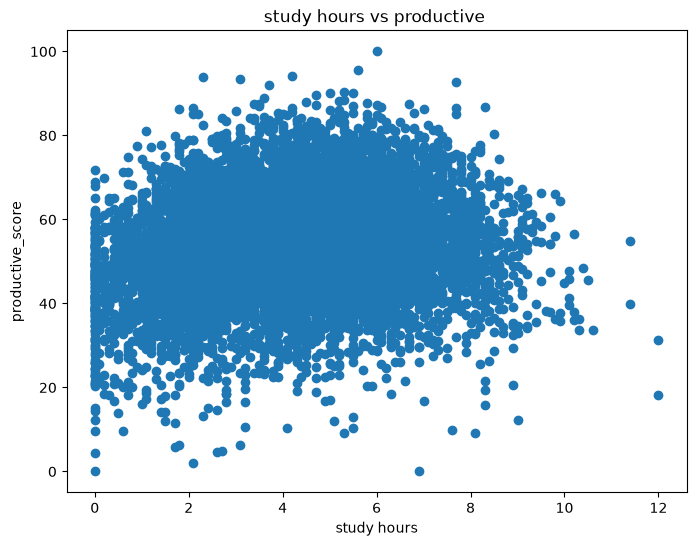

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(df["Study_Hours_Per_Day"],
df["Productivity_Score"])
plt.xlabel("study hours")
plt.ylabel("productive_score")
plt.title("study hours vs productive ")
plt.show()

In [ ]:
!pip install seaborn 


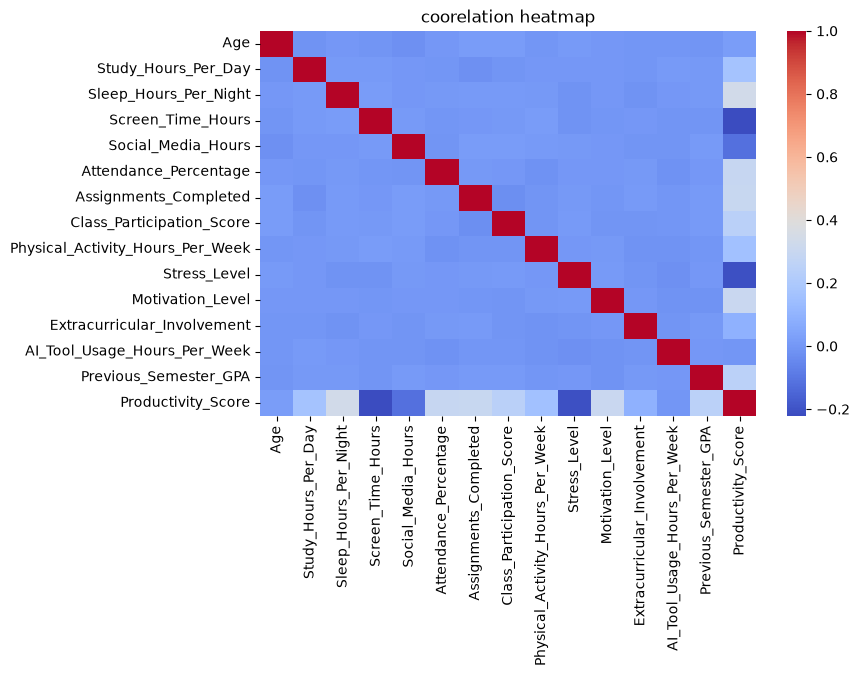

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes('float64','int64').corr(),
cmap='coolwarm')
plt.title("coorelation heatmap")
plt.show() 


In [49]:
correlation = df.select_dtypes(include=['float64','int64']).corr()

print(correlation['Productivity_Score'].sort_values(ascending=False))

Productivity_Score                  1.000000
Sleep_Hours_Per_Night               0.334172
Motivation_Level                    0.298758
Assignments_Completed               0.298060
Attendance_Percentage               0.291484
Previous_Semester_GPA               0.247186
Class_Participation_Score           0.243159
Study_Hours_Per_Day                 0.165535
Physical_Activity_Hours_Per_Week    0.157299
Extracurricular_Involvement         0.091540
Age                                 0.018027
AI_Tool_Usage_Hours_Per_Week       -0.003744
Student_ID                         -0.013841
Social_Media_Hours                 -0.117155
Stress_Level                       -0.210890
Screen_Time_Hours                  -0.221317
Name: Productivity_Score, dtype: float64


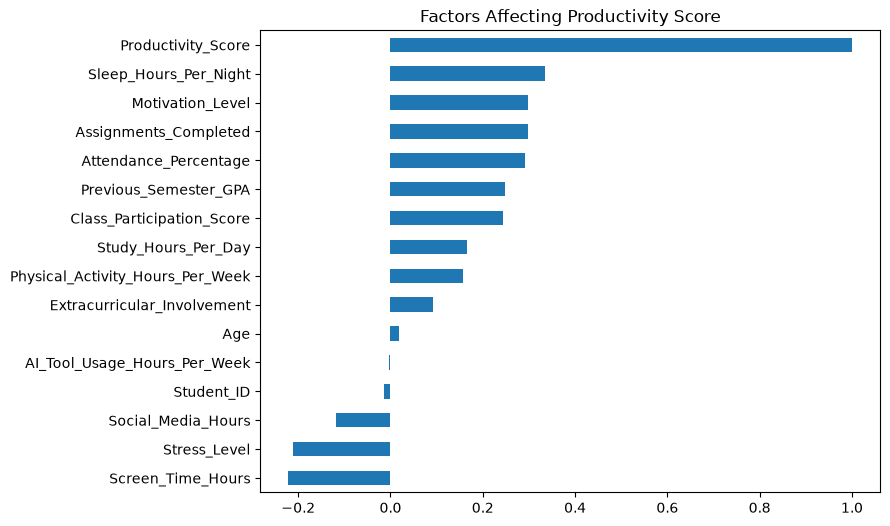

In [50]:
corr = correlation['Productivity_Score'].sort_values()

corr.plot(kind='barh', figsize=(8,6))

plt.title("Factors Affecting Productivity Score")
plt.show()

In [53]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 5.3 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.3 MB 7.6 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.3 MB 7.7 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 7.0 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 6.6 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.8 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.8/37.3 MB 9.5 MB/s eta 0:00:04
   ---- ----------------------------------- 3.9/37.3 MB 9.7 MB/s eta 0:00:04
   ------ --------------------------------- 5.8/37.3 MB 9.5 MB/s eta 0:00:04
   ------- -------------------------------- 7.1/37.3 MB 8.4 MB/s eta 0:00:04
   --------- -----------

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


df_ml = pd.get_dummies(df, drop_first=True)

X = df_ml.drop("Productivity_Score", axis=1)
y = df_ml["Productivity_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2 Score: 0.8508185530160213
MAE: 3.7644858999999995


In [56]:
import joblib
joblib.dump(model,"productivity_model.pkl")
print("model saved succesful") 


model saved succesful


In [58]:
loaded_model =joblib.load("productivity_model.pkl")
print("model loaded succesful")

model loaded succesful


In [59]:
sample_student = X_test.iloc[[0]]
prediction = loaded_model.predict(sample_student)

print("predicted productive score :",prediction[0])
print("actuall score :",y_test.iloc[0])

predicted productive score : 54.21000000000003
actuall score : 53.29


In [62]:
X.columns

Index(['Student_ID', 'Age', 'Study_Hours_Per_Day', 'Sleep_Hours_Per_Night',
       'Screen_Time_Hours', 'Social_Media_Hours', 'Attendance_Percentage',
       'Assignments_Completed', 'Class_Participation_Score',
       'Physical_Activity_Hours_Per_Week', 'Stress_Level', 'Motivation_Level',
       'Extracurricular_Involvement', 'AI_Tool_Usage_Hours_Per_Week',
       'Previous_Semester_GPA', 'Gender_Male', 'Gender_Other',
       'Internet_Quality_Good', 'Internet_Quality_Poor', 'Part_Time_Job_Yes',
       'Performance_Category_Low', 'Performance_Category_Medium'],
      dtype='str')

In [66]:
X.mean(numeric_only =True)
X.mode().iloc[0]

Student_ID                                 1
Age                                     19.0
Study_Hours_Per_Day                      4.3
Sleep_Hours_Per_Night                    7.2
Screen_Time_Hours                        1.0
Social_Media_Hours                       0.0
Attendance_Percentage                  100.0
Assignments_Completed                  100.0
Class_Participation_Score               10.0
Physical_Activity_Hours_Per_Week         1.6
Stress_Level                            10.0
Motivation_Level                        10.0
Extracurricular_Involvement              0.0
AI_Tool_Usage_Hours_Per_Week             2.4
Previous_Semester_GPA               6.489753
Gender_Male                            False
Gender_Other                           False
Internet_Quality_Good                  False
Internet_Quality_Poor                  False
Part_Time_Job_Yes                      False
Performance_Category_Low               False
Performance_Category_Medium            False
Name: 0, d

In [67]:
X.columns.tolist()

['Student_ID',
 'Age',
 'Study_Hours_Per_Day',
 'Sleep_Hours_Per_Night',
 'Screen_Time_Hours',
 'Social_Media_Hours',
 'Attendance_Percentage',
 'Assignments_Completed',
 'Class_Participation_Score',
 'Physical_Activity_Hours_Per_Week',
 'Stress_Level',
 'Motivation_Level',
 'Extracurricular_Involvement',
 'AI_Tool_Usage_Hours_Per_Week',
 'Previous_Semester_GPA',
 'Gender_Male',
 'Gender_Other',
 'Internet_Quality_Good',
 'Internet_Quality_Poor',
 'Part_Time_Job_Yes',
 'Performance_Category_Low',
 'Performance_Category_Medium']